In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

In [14]:
df = pd.read_csv("thyroid_dataset.csv")
df.head()
df.shape
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6916 entries, 0 to 6915
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        6916 non-null   float64
 1   Sex                        6916 non-null   int64  
 2   on_thyroxine               6916 non-null   int64  
 3   query_on_thyroxine         6916 non-null   int64  
 4   on_antithyroid_medication  6916 non-null   int64  
 5   sick                       6916 non-null   int64  
 6   pregnant                   6916 non-null   int64  
 7   thyroid_surgery            6916 non-null   int64  
 8   I131_treatment             6916 non-null   int64  
 9   query_hypothyroid          6916 non-null   int64  
 10  query_hyperthyroid         6916 non-null   int64  
 11  lithium                    6916 non-null   int64  
 12  goitre                     6916 non-null   int64  
 13  tumor                      6916 non-null   int64

In [15]:
X = df.drop("Outlier_label",axis=1)
y = df["Outlier_label"]

In [16]:
X.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,lithium,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,61.0,6.0,23.0,87.0,26.0
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,29.0,15.0,61.0,96.0,64.0
2,0.16,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,29.0,19.0,58.0,103.0,56.0
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,114.0,3.0,24.0,61.0,39.0
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,49.0,3.0,5.0,116.0,4.0


In [19]:
## Standardize our data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
X_scaled

array([[-2.34449113e-02,  1.50050924e+00, -3.94405319e-01, ...,
        -1.40951598e+00, -3.74590514e-02, -1.25859776e+00],
       [ 2.40791602e-03, -6.66440415e-01, -3.94405319e-01, ...,
        -6.57814578e-01,  2.27969782e-01, -5.68029663e-01],
       [-7.03031607e-02, -6.66440415e-01,  2.53546276e+00, ...,
        -7.17159426e-01,  4.34414431e-01, -7.13412420e-01],
       ...,
       [-2.99081181e-02, -6.66440415e-01, -3.94405319e-01, ...,
         6.08208844e-01,  7.58827450e-01,  2.49748343e-01],
       [ 7.25532113e-03,  1.50050924e+00, -3.94405319e-01, ...,
         2.32358141e-01, -7.96695877e-03,  4.67822478e-01],
       [-2.18291096e-02, -6.66440415e-01, -3.94405319e-01, ...,
        -2.48028670e-02,  8.05093192e-02,  1.22538431e-01]],
      shape=(6916, 21))

In [31]:
isolation_forest = IsolationForest(n_estimators=300,contamination=0.036,random_state=42)

In [32]:
labels = isolation_forest.fit_predict(X_scaled)

In [33]:
labels

array([ 1,  1, -1, ...,  1,  1,  1], shape=(6916,))

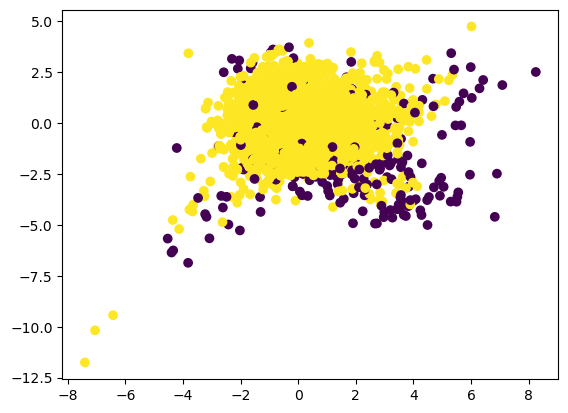

In [34]:
## Visualize our data
pca = PCA(n_components=2)
x_pca = pca.fit_transform(X_scaled)
plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=labels
)

In [35]:
## print the actual no the outliers that isolation detected
import numpy as np
n_outlier = np.sum(labels == -1)
print("outlier exists:",n_outlier)

outlier exists: 249


# LOF

In [36]:
from sklearn.neighbors import LocalOutlierFactor

In [38]:
lof = LocalOutlierFactor()
labels = lof.fit_predict(X_scaled)

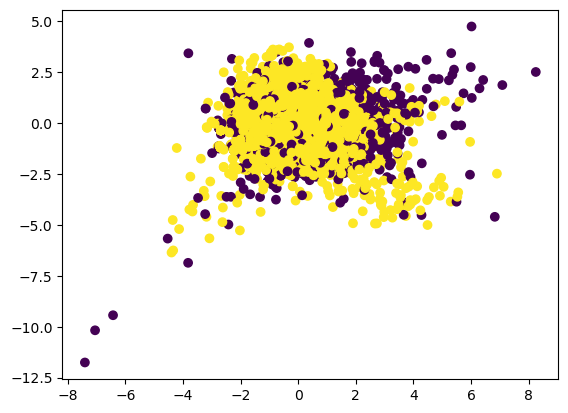

In [39]:
plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=labels
)

In [40]:
import numpy as np
n_outlier = np.sum(labels == -1)
print("outlier exists:",n_outlier)

outlier exists: 883
